# iFood Customer Behavior — Exploratory Data Analysis (EDA)

## Import necessary libraries and conect to the database

In [3]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import itables
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [4]:

# ============================================================
# Connection Setup
# ============================================================
server   = 'DESKTOP-931U322\SQLEXPRESS'
database = 'MarketingCampaign_DB'

engine = create_engine(
    f'mssql+pyodbc://{server}/{database}'
    f'?driver=ODBC+Driver+17+for+SQL+Server'
    f'&trusted_connection=yes'
)

# ============================================================
# Load Views into DataFrames
# ============================================================
df_customer  = pd.read_sql('SELECT * FROM vw_Customer',  engine)
df_spending  = pd.read_sql('SELECT * FROM vw_Spending',  engine)
df_purchases = pd.read_sql('SELECT * FROM vw_Purchases', engine)
df_campaigns = pd.read_sql('SELECT * FROM vw_Campaigns', engine)
df_segments  = pd.read_sql('SELECT * FROM vw_Segments',  engine)

# ============================================================
# Merge all Views on ID
# ============================================================
df = (
    df_customer
    .merge(df_spending,  on='ID', how='left')
    .merge(df_purchases, on='ID', how='left')
    .merge(df_campaigns, on='ID', how='left')
    .merge(df_segments,  on='ID', how='left')
)


## Q1: What does the data look like?

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2037 entries, 0 to 2036
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      2037 non-null   int64  
 1   Year_Birth              2037 non-null   int64  
 2   Age                     2037 non-null   int64  
 3   AgeGroup_x              2037 non-null   object 
 4   Education               2037 non-null   object 
 5   Marital_Status          2037 non-null   object 
 6   Income                  2037 non-null   float64
 7   Kidhome                 2037 non-null   int64  
 8   Teenhome                2037 non-null   int64  
 9   HasChildren_x           2037 non-null   object 
 10  Country                 2037 non-null   object 
 11  Dt_Customer             2037 non-null   object 
 12  CustomerTenure          2037 non-null   int64  
 13  MntWines                2037 non-null   float64
 14  MntFruits               2037 non-null   

In [6]:
itables.show(df)

Loading ITables v2.5.2 from the internet... (need help?)


In [7]:
itables.show(df.describe())

Loading ITables v2.5.2 from the internet... (need help?)


## Q2: What is the income distribution?

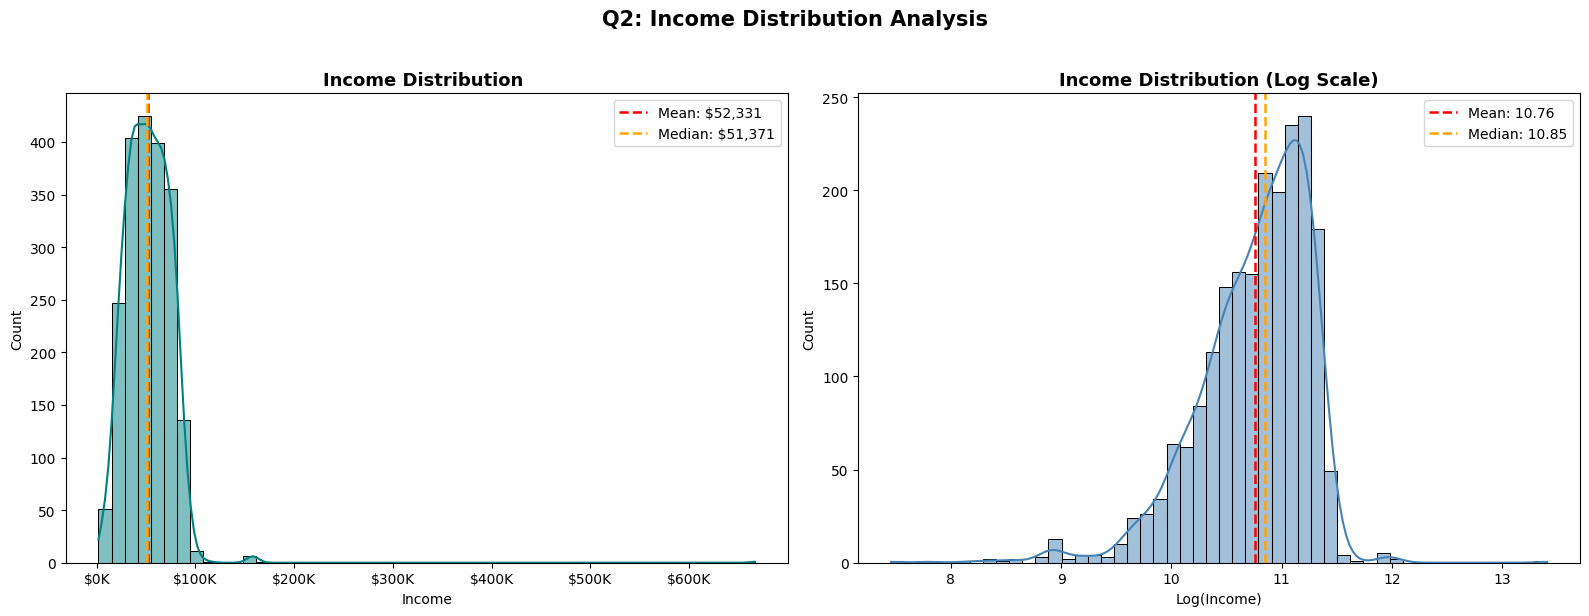

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============ Plot 1: Original Distribution ============
ax1 = axes[0]
sns.histplot(df['Income'], bins=50, kde=True, color='teal', ax=ax1)


ax1.axvline(df['Income'].mean(),   color='red',    linestyle='--', linewidth=1.8, label=f"Mean: ${df['Income'].mean():,.0f}")
ax1.axvline(df['Income'].median(), color='orange', linestyle='--', linewidth=1.8, label=f"Median: ${df['Income'].median():,.0f}")

ax1.set_title('Income Distribution ', fontsize=13, fontweight='bold')
ax1.set_xlabel('Income')
ax1.set_ylabel('Count')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.legend()

# ============ Plot 2: Log-Transformed Distribution ============
ax2 = axes[1]
log_income = np.log1p(df['Income'])
sns.histplot(log_income, bins=50, kde=True, color='steelblue', ax=ax2)

ax2.axvline(log_income.mean(),   color='red',    linestyle='--', linewidth=1.8, label=f"Mean: {log_income.mean():.2f}")
ax2.axvline(log_income.median(), color='orange', linestyle='--', linewidth=1.8, label=f"Median: {log_income.median():.2f}")

ax2.set_title('Income Distribution (Log Scale)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Log(Income)')
ax2.set_ylabel('Count')
ax2.legend()



plt.suptitle('Q2: Income Distribution Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> ### insights
- The distribution is right-skewed — most people earn between $30K–$80K, but a small group with very high incomes (up to $600K+) pulls the Mean above the Median.
- Mean ($52,331) > Median ($51,371) — the gap is small but confirms the right skew caused by high-income outliers.

## Q3: Does income affect total spending?

Loading ITables v2.5.2 from the internet... (need help?)


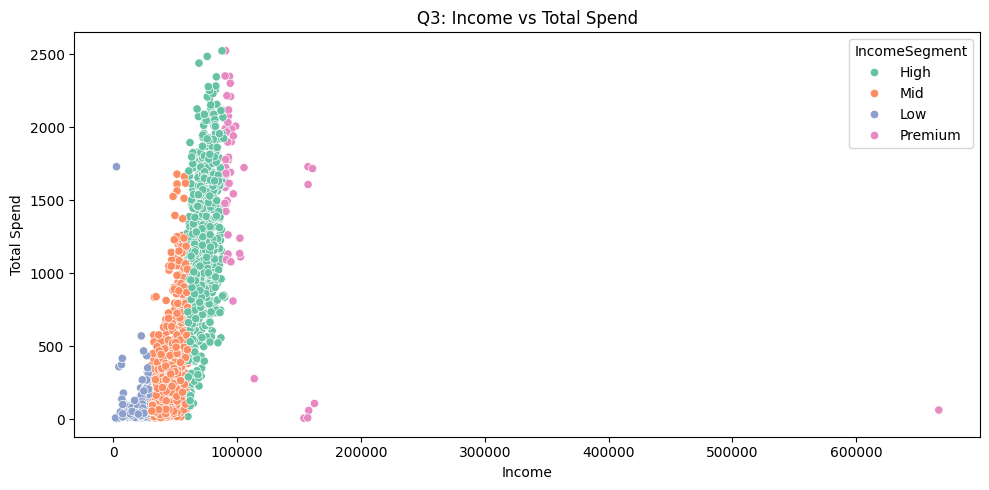

In [9]:
itables.show(
    df.groupby('IncomeSegment')['TotalSpend']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
    .round(2)
)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Income', y='TotalSpend',
                hue='IncomeSegment', palette='Set2')
plt.title('Q3: Income vs Total Spend')
plt.xlabel('Income')
plt.ylabel('Total Spend')
plt.tight_layout()
plt.show()

> ### insights
 - **Income segments show distinct spending patterns** — Premium customers reach up to $2,500 in Total Spend while Low segment customers rarely exceed $500, confirming that higher income groups are consistently bigger spenders.

 - **Spending behavior is highly unpredictable at the individual level** — even within the same income segment, Total Spend varies drastically, with some customers earning under $50,000 spending as much as those earning $100,000+, suggesting factors like lifestyle or personal preferences play a stronger role than income alone.

## Q4: Which age group spends the most?

In [10]:
age_spend = df.groupby('AgeGroup_x')['TotalSpend'].mean().sort_values(ascending=False)
itables.show(age_spend)


Loading ITables v2.5.2 from the internet... (need help?)


> ### insights

- **Older customers spend significantly more** — the 60+ age group leads with an average spend of $741, nearly 44% higher than the lowest group (30-39 at $516), suggesting that older customers have more disposable income or stronger purchasing habits.

- **Spending doesn't increase linearly with age** — the 18-29 group ($595) spends more than both the 30-39 ($516) and 40-49 ($559) groups, which is unexpected and suggests that **young adults may be more impulsive spenders** despite likely earning less than middle-aged groups.

## Q5: Which product category generates the most revenue?

Loading ITables v2.5.2 from the internet... (need help?)


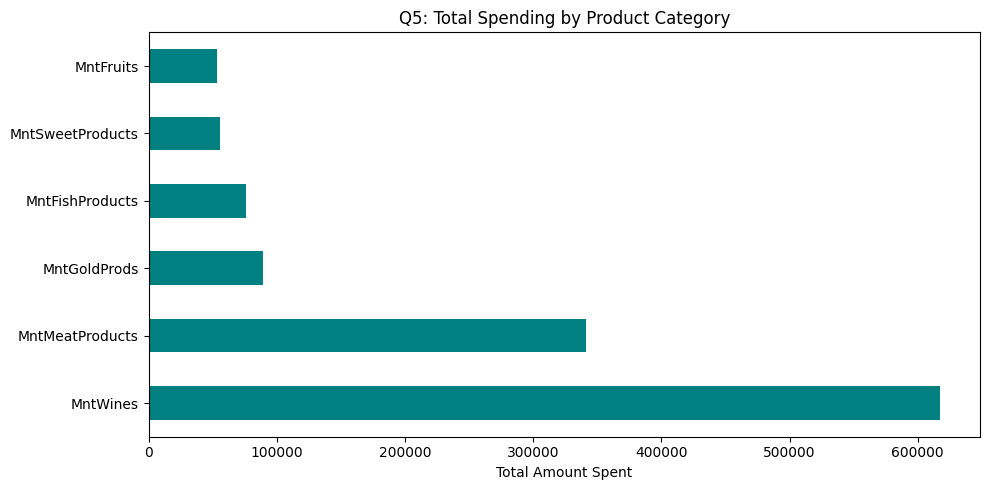

In [11]:
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

product_totals = df[product_cols].sum().sort_values(ascending=False)

product_totals_df = product_totals.reset_index()
product_totals_df.columns = ['Product', 'Total Spend']
product_totals_df['% of Total'] = (product_totals_df['Total Spend'] / 
                                    product_totals_df['Total Spend'].sum() * 100).round(2)

itables.show(product_totals_df)

plt.figure(figsize=(10, 5))
product_totals.plot(kind='barh', color='teal')
plt.title('Q5: Total Spending by Product Category')
plt.xlabel('Total Amount Spent')
plt.tight_layout()
plt.show()

> ### insights 
- **Wines dominate customer spending** — MntWines alone accounts for 50% of total spend at $617,731, meaning half of all customer expenditure goes exclusively to wines.

- **Wines and Meat together drive the majority of revenue** — combining MntWines (50.08%) and MntMeatProducts (27.68%) accounts for nearly 78% of total spend, making them by far the most critical product categories for the business.

## Q6: Which campaign performed best?

In [12]:
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

campaign_totals = df[campaign_cols].sum().sort_values(ascending=False)

campaign_totals_df = campaign_totals.reset_index()
campaign_totals_df.columns = ['Campaign', 'Total Accepted']
campaign_totals_df['Acceptance Rate %'] = (campaign_totals_df['Total Accepted'] / 
                                            len(df) * 100).round(2)

itables.show(campaign_totals_df)


Loading ITables v2.5.2 from the internet... (need help?)


> ### insights

-  **Response campaign is the most successful** — with a 14.97% acceptance rate, it's nearly double the second-best campaign (AcceptedCmp4 at 7.61%), making it by far the most effective campaign.

-  **Campaigns 3, 4, and 5 perform similarly** — all three sit between 7.17% and 7.61%, suggesting they share similar targeting strategies or audience segments.

-  **Campaign 2 is significantly underperforming** — with only 1.28% acceptance rate, it's dramatically lower than all other campaigns and should be reviewed or discontinued.

## Q7: How are customers distributed across RFM segments?

In [13]:
rfm_counts = df['RFM_Segment'].value_counts().reset_index()
rfm_counts.columns = ['RFM Segment', 'Count']
rfm_counts['% of Customers'] = (rfm_counts['Count'] / 
                                  rfm_counts['Count'].sum() * 100).round(2)

itables.show(rfm_counts)


Loading ITables v2.5.2 from the internet... (need help?)


> ### insights

- **Loyal and Regular customers form the backbone of the business** — together they represent 77.72% of all customers (42.91% + 34.81%), meaning the majority of the customer base is already engaged and returning.

- **VIP customers are a small but valuable segment** — at only 8.64% (176 customers), they drive a disproportionately high share of revenue and should be prioritized for retention and exclusive offers.

- **At Risk and Inactive segments are reassuringly small** — combined they represent only 8.69% of customers (3.83% + 4.86%), which is a positive sign indicating that the business is doing well at retaining its customer base and preventing churn.

## Q8: Do customers with children spend less?

In [14]:
# Group by with stats
children_spend = df.groupby('HasChildren_x')['TotalSpend'].agg(['mean', 'count']).round(2)
# children_spend.index = ['No Children', 'Has Children']
children_spend.columns = ['Mean Spend', 'Count']
itables.show(children_spend)


Loading ITables v2.5.2 from the internet... (need help?)


> ### insights

- **Customers with children spend significantly less** — with Children group averages $405.62 compared to $1,116.35 for No Children, 


## Q9: What is the correlation between numeric columns?

                          Income  TotalSpend  TotalPurchases  \
Income                  1.000000    0.649597        0.608219   
TotalSpend              0.649597    1.000000        0.819365   
TotalPurchases          0.608219    0.819365        1.000000   
TotalCampaignsAccepted  0.281584    0.453044        0.302528   
Recency                -0.007249    0.015006        0.001657   
Age                     0.160098    0.117367        0.171144   
CustomerTenure         -0.013087    0.168672        0.169636   

                        TotalCampaignsAccepted   Recency       Age  \
Income                                0.281584 -0.007249  0.160098   
TotalSpend                            0.453044  0.015006  0.117367   
TotalPurchases                        0.302528  0.001657  0.171144   
TotalCampaignsAccepted                1.000000 -0.096334 -0.022720   
Recency                              -0.096334  1.000000  0.024077   
Age                                  -0.022720  0.024077  1.000000 

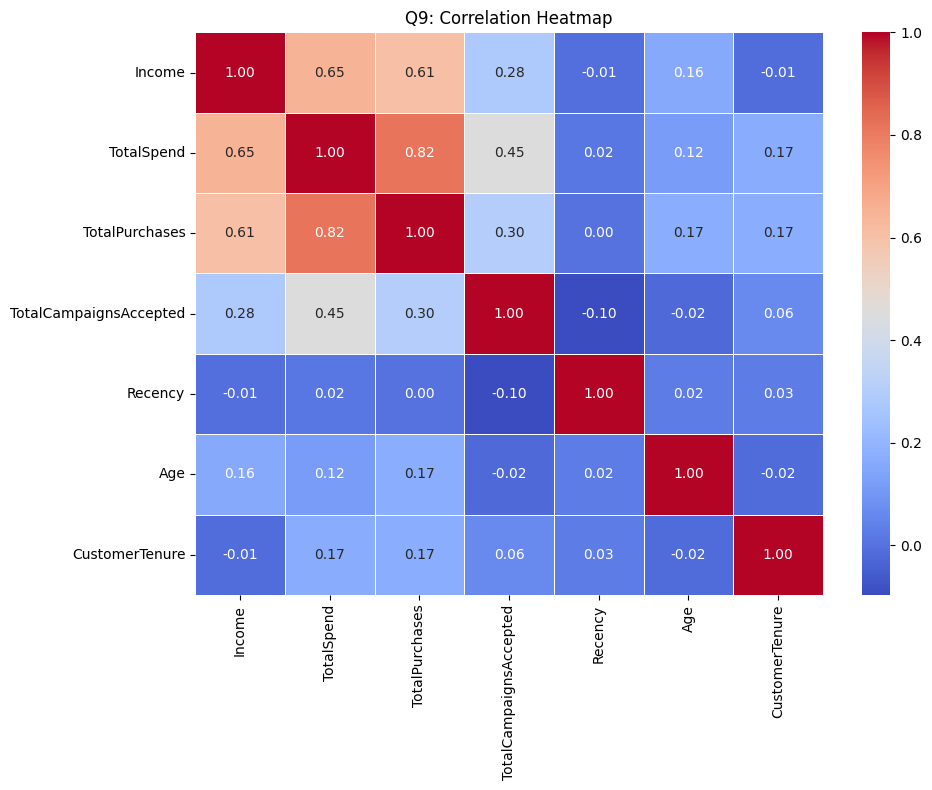

In [15]:
numeric_cols = ['Income', 'TotalSpend', 'TotalPurchases',
                'TotalCampaignsAccepted', 'Recency',
                'Age', 'CustomerTenure']

corr = df[numeric_cols].corr()
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Q9: Correlation Heatmap')
plt.tight_layout()
plt.show()

> ### insights

- **TotalSpend and TotalPurchases have the strongest relationship** — at 0.82, meaning the more a customer purchases, the higher their spend, which is the most significant correlation in the entire matrix.

- **Income has a moderate positive relationship with Spend and Purchases** — at 0.65 and 0.61 respectively, confirming that income is an important but not the sole driver of spending behavior.

- **Recency shows virtually no correlation with anything** — all values close to zero, meaning the time since a customer's last purchase has no meaningful impact on their spending or purchasing patterns.

- **Age and CustomerTenure have weak correlations across all variables** — all values below 0.17, suggesting that a customer's age and how long they've been with the business are not key factors in determining their buying behavior.

## Q10: Do long-tenure customers spend more?

Loading ITables v2.5.2 from the internet... (need help?)


C:\Users\w\AppData\Local\Temp\ipykernel_59176\2491929059.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\w\AppData\Local\Temp\ipykernel_59176\2491929059.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


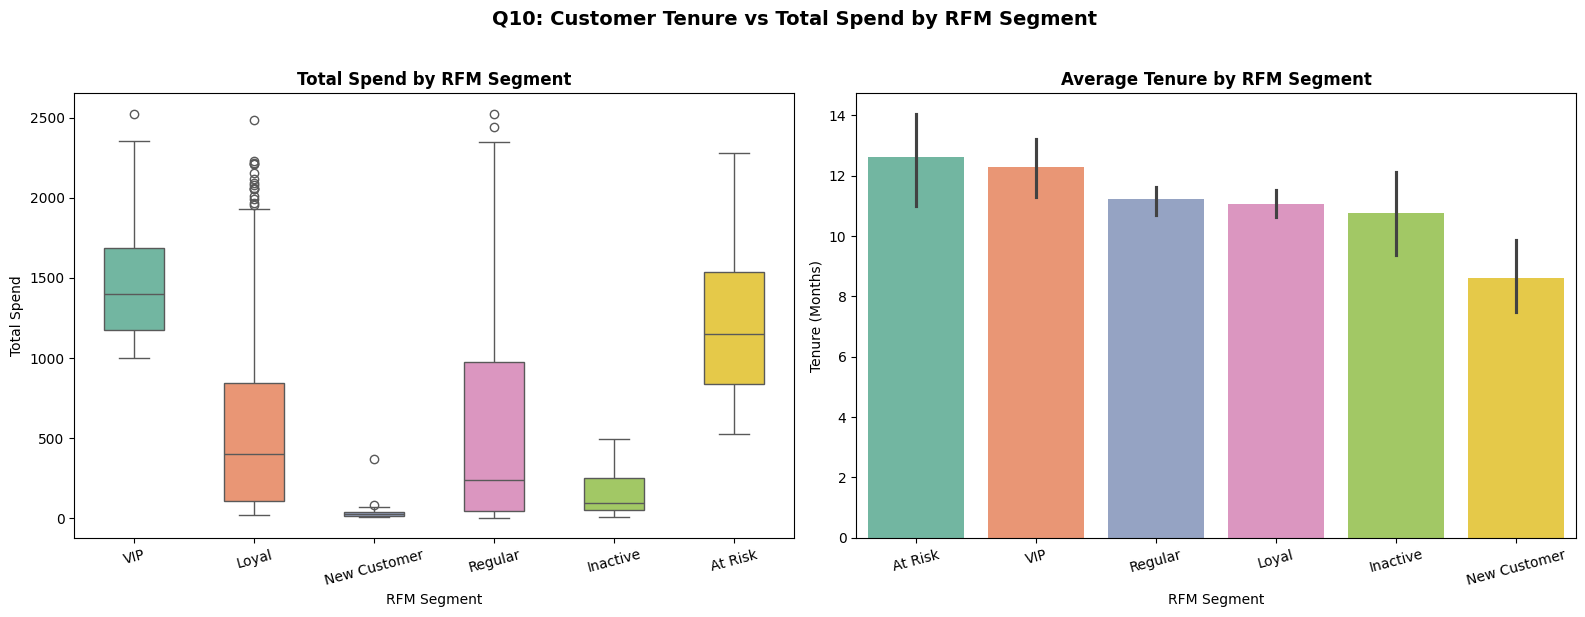

In [ ]:
tenure_rfm = df.groupby('RFM_Segment').agg(
    Mean_Tenure=('CustomerTenure', 'mean'),
    Mean_Spend=('TotalSpend', 'mean'),
    Count=('TotalSpend', 'count')
).round(2).sort_values('Mean_Spend', ascending=False)

itables.show(tenure_rfm)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============ Plot 1: Boxplot ============
sns.boxplot(
    data=df,
    x='RFM_Segment',
    y='TotalSpend',
    palette='Set2',
    ax=axes[0],
    width=0.5
)
axes[0].set_title('Average Spend by RFM Segment', fontweight='bold')
axes[0].set_xlabel('RFM Segment')
axes[0].set_ylabel('Total Spend')
axes[0].tick_params(axis='x', rotation=15)

# ============ Plot 2: Barplot ============
sns.barplot(
    data=df,
    x='RFM_Segment',
    y='CustomerTenure',
    palette='Set2',
    ax=axes[1],
    order=df.groupby('RFM_Segment')['CustomerTenure'].mean().sort_values(ascending=False).index
)
axes[1].set_title('Average Tenure by RFM Segment', fontweight='bold')
axes[1].set_xlabel('RFM Segment')
axes[1].set_ylabel('Tenure (Months)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Q10: Customer Tenure vs Total Spend by RFM Segment',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> ### insights

- **VIP customers spend the most but At Risk customers have the longest tenure** — VIP averages $1,447 in spend while At Risk customers have been with the business for 12.62 months on average, meaning the business is at risk of losing some of its most experienced customers.

- **New Customers have the lowest tenure and spend** — with only 8.62 months average tenure and $33.58 mean spend, they haven't yet developed strong purchasing habits, highlighting the need for better onboarding and engagement strategies.
